In [1]:
import pandas as pd # library to set and manipulate input data
import doestat as doe # DoEStat 

#### Khajeh, M. (2012) *Multivariate Optimization of Microwave-Assisted Digestion of Copper and Zinc from Powder Milk*

In [2]:
# Import data, set matrix X and set vector y
# Fullfact Design
df3 = pd.read_excel("test.xlsx", sheet_name="Khajeh1")
X3 = df3.iloc[:,:4]
y3 = df3.iloc[:,4:]
yc3 = df3.iloc[16:,4:]

In [3]:
# Show the input data
print("--"*30)
print("Dataframe")
print("--"*30)
print(df3)
print("")
print("--"*30)
print("Matrix X")
print("--"*30)
print(X3)
print("")
print("--"*30)
print("Vector y")
print("--"*30)
print(y3)
print("")
print("--"*30)
print("Central Points")
print("--"*30)
print(yc3)

------------------------------------------------------------
Dataframe
------------------------------------------------------------
    Power/W  Temperature/ºC  time/min  Volume/mL  Amount
0        -1              -1        -1         -1   66.86
1         1              -1        -1         -1   68.38
2        -1               1        -1         -1   62.98
3         1               1        -1         -1   66.52
4        -1              -1         1         -1   59.30
5         1              -1         1         -1   65.37
6        -1               1         1         -1   63.54
7         1               1         1         -1   75.04
8        -1              -1        -1          1   53.15
9         1              -1        -1          1   58.32
10       -1               1        -1          1   54.19
11        1               1        -1          1   67.03
12       -1              -1         1          1   47.20
13        1              -1         1          1   58.64
14       -1  

['Power/W', 'Temperature/ºC', 'time/min', 'Volume/mL', 'Power/W × Temperature/ºC', 'Power/W × time/min', 'Power/W × Volume/mL', 'Temperature/ºC × time/min', 'Temperature/ºC × Volume/mL', 'time/min × Volume/mL', 'Power/W × Temperature/ºC × time/min', 'Power/W × Temperature/ºC × Volume/mL', 'Power/W × time/min × Volume/mL', 'Temperature/ºC × time/min × Volume/mL', 'Power/W × Temperature/ºC × time/min × Volume/mL']


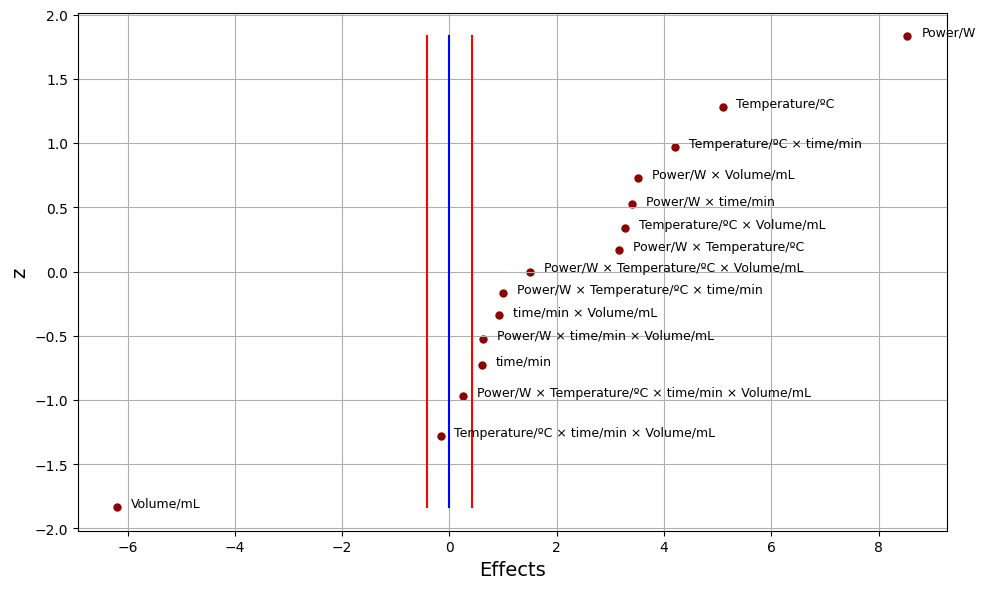

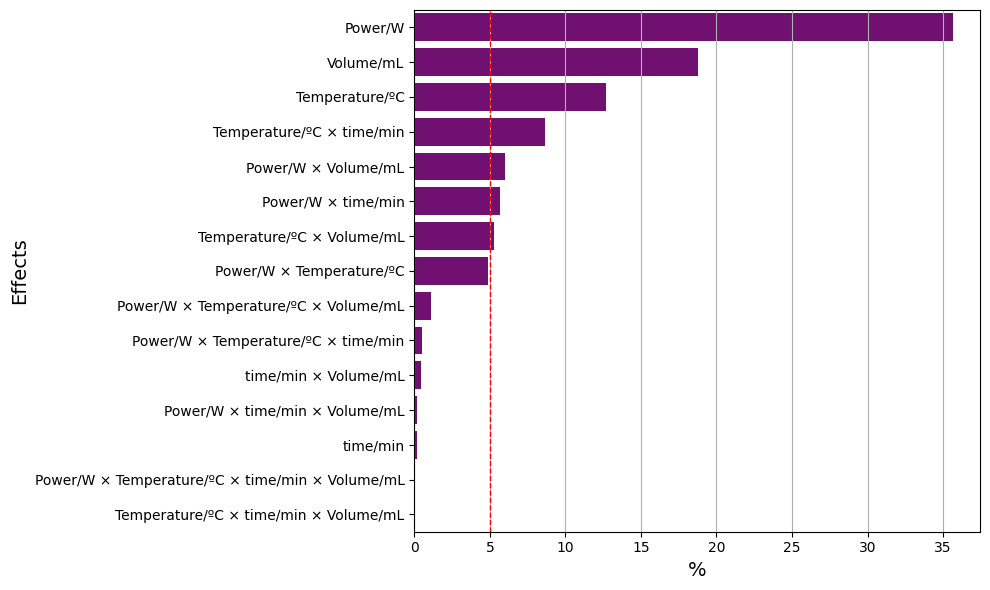

In [4]:
# Effects analysis
# The output was used for build Figure 10
doe.Analysis(X3,y3,yc3, type_matrix='interaction', effect_error='cp').effect_analysis()

In [5]:
# ANOVA for fullfact matrix
doe.Regression(X3,y3,yc3,type_matrix='interaction',effect_error='cp', regression='linear').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,1034.965,15,68.998,7896.727,F(0.05;15;2) = 19.429,406.437,1.2663e-04
1,Residual,0.017,2,0.009,,,,
2,Total,1034.982,17,60.881,,,,
3,Pure Error,0.008,1,0.008,1.068,F(0.05;1;1) = 161.448,0.007,4.8952e-01
4,Lack of Fit,0.009,1,0.009,,,,


In [6]:
# Import data, set matrix X and set vector y
# Box–Behnken Design (BBD)
df4 = pd.read_excel("test.xlsx", sheet_name='Khajeh2')
X4 = df4.iloc[:,:4]
yzn = df4.iloc[:,4:5]
ycu = df4.iloc[:,5:]
yczn = df4.iloc[24:,4:5]
yccu = df4.iloc[24:,5:]

In [7]:
# Show the input data
print("--"*30)
print("Dataframe")
print("--"*30)
print(df4)
print("")
print("--"*30)
print("Matrix X")
print("--"*30)
print(X4)
print("")
print("--"*30)
print("Vector y for Zinc")
print("--"*30)
print(yzn)
print("")
print("--"*30)
print("Vector y for Copper")
print("--"*30)
print(ycu)
print("")
print("--"*30)
print("Central Points of Zinc")
print("--"*30)
print(yczn)
print("")
print("--"*30)
print("Central Points of Copper")
print("--"*30)
print(yccu)
print("")

------------------------------------------------------------
Dataframe
------------------------------------------------------------
    Power/W  Temperature/ºC  time/min  Volume/mL     Zn    Cu
0        -1              -1         0          0  69.66  2.98
1         1              -1         0          0  75.28  3.36
2        -1               1         0          0  72.47  1.94
3         1               1         0          0  91.66  5.62
4         0               0        -1         -1  71.71  4.14
5         0               0         1         -1  64.85  3.98
6         0               0        -1          1  68.36  3.61
7         0               0         1          1  70.23  4.29
8        -1               0        -1          0  68.65  4.31
9         1               0        -1          0  74.57  3.92
10       -1               0         1          0  62.32  2.79
11        1               0         1          0  77.58  6.15
12        0              -1         0         -1  69.47  3.95


In [8]:
# ANOVA for Zinc
# The output was used to build the table 7
doe.Regression(X4,yzn,yczn,effect_error='cp',regression='quadratic').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,1303.857,8,162.982,10.668,F(0.05;8;18) = 2.51,4.25,1.9476e-05
1,Residual,274.986,18,15.277,,,,
2,Total,1578.843,26,60.725,,,,
3,Pure Error,1.630,2,0.815,20.962,F(0.05;16;2) = 19.433,1.079,4.6450e-02
4,Lack of Fit,273.356,16,17.085,,,,


In [9]:
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Power/W', 'Temperature/ºC']).surface(v1=[300, 500], v2=[80, 120],plot3D=True, significant_coeff=True)


In [10]:
# Surface response for Zinc
# The output was used to build the figure 13

# Power versus Temperature
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Power/W', 'Temperature/ºC']).surface(v1=[300, 500], v2=[80, 120],plot3D=True, significant_coeff=True)

# Power versus time
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Power/W', 'time/min']).surface(v1=[300, 500], v2=[16, 30],plot3D=True, significant_coeff=True)

# Power versus Volume
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Power/W', 'Volume/mL']).surface(v1=[300, 500], v2=[2, 6],plot3D=True, significant_coeff=True)

# Temperature versus time
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Temperature/ºC', 'time/min']).surface(v1=[80, 120], v2=[16, 30],plot3D=True, significant_coeff=True)

# Temperature versus Volume
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['Temperature/ºC', 'Volume/mL']).surface(v1=[80, 120], v2=[2, 6],plot3D=True, significant_coeff=True)

# time verus Volume
doe.Regression(X4,yzn,yczn,
               type_matrix='interaction',
               effect_error='cp',
               regression='quadratic',
               selected_factors=['time/min', 'Volume/mL']).surface(v1=[16, 30], v2=[2, 6],plot3D=True)


#### Vicentini et al. (2011) *Optimized voltametric method for Ag determination*

In [11]:
# Import data, set matrix X and set vector y
# Fullfact Design
df6 = pd.read_excel("test.xlsx", sheet_name='Vicentini')
X6 = df6.iloc[:,:2]
y6 = df6.iloc[:,2:]
yc6 = df6.iloc[4:7,2:]


In [12]:
doe.Regression(X6,y6,yc6,type_matrix='interaction', effect_error='cp').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,1220.115,5,244.023,53.664,F(0.05;5;5) = 5.05,10.626,2.4109e-04
1,Residual,22.736,5,4.547,,,,
2,Total,1242.851,10,124.285,,,,
3,Pure Error,9.312,2,4.656,0.961,F(0.05;3;2) = 19.164,0.05,5.4632e-01
4,Lack of Fit,13.424,3,4.475,,,,


In [13]:
doe.Regression(X6,y6,yc6,type_matrix='interaction', effect_error='cp').show_equation(significant_coeff=True)

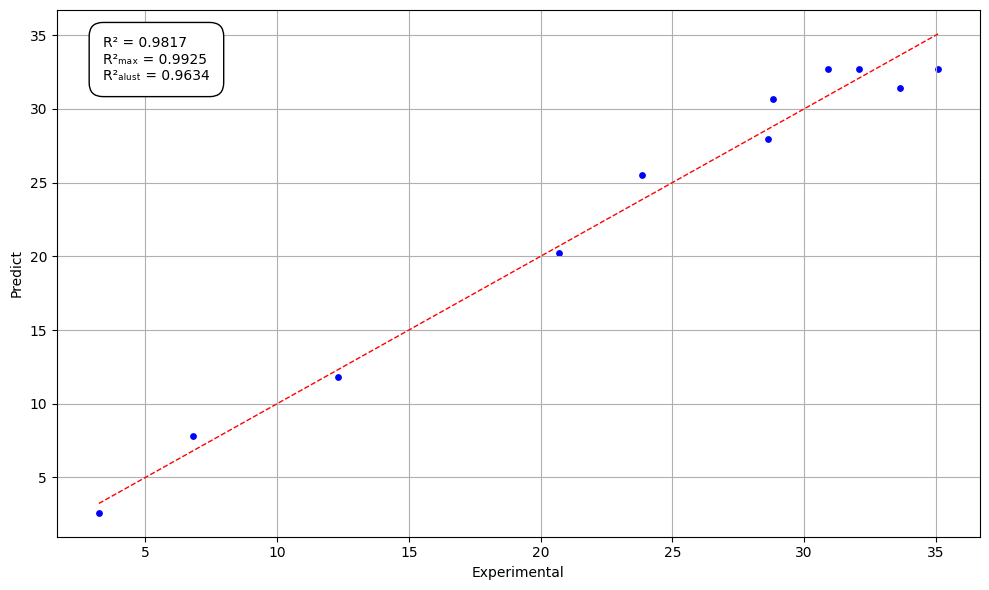

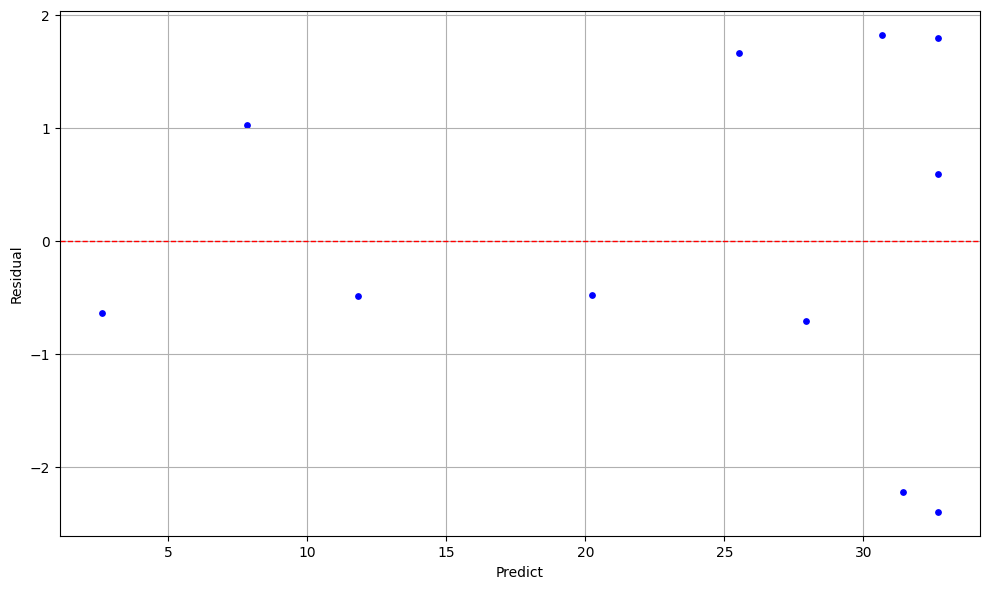

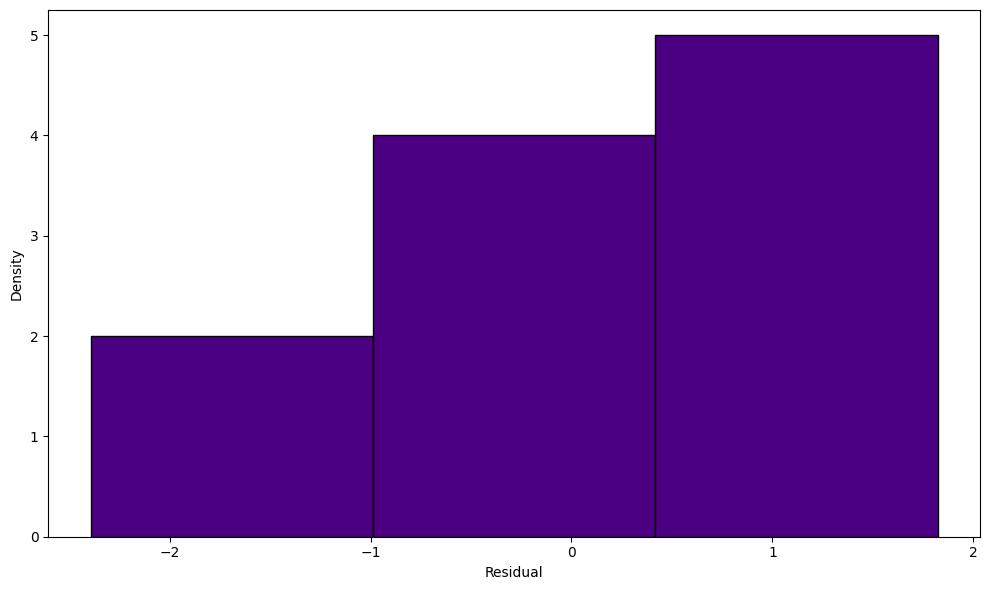

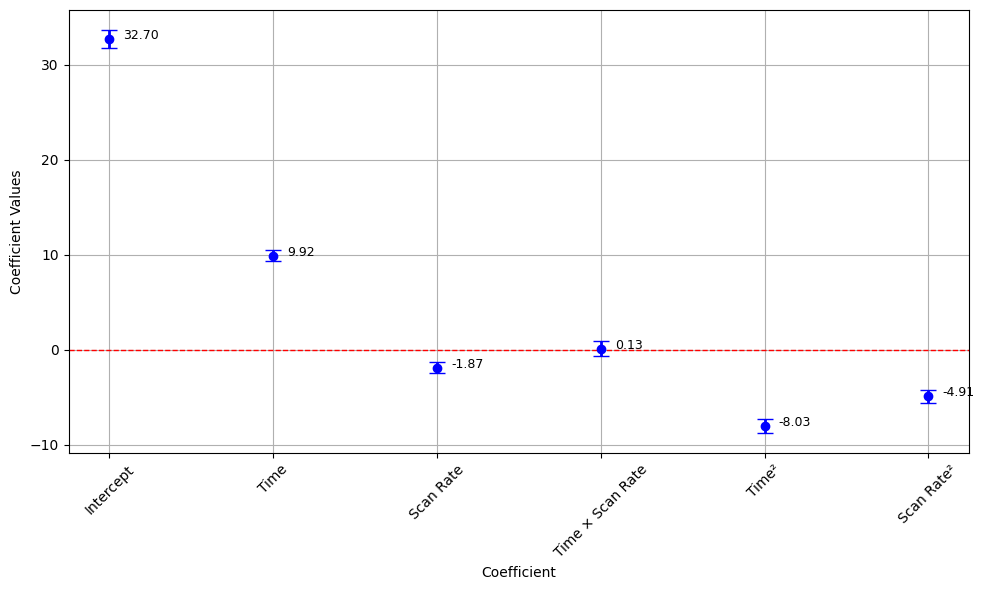

In [14]:
doe.Regression(X6,y6,yc6,type_matrix='interaction', effect_error='cp').analysis

#### Conceição et al. (2015) *Ethanolysis optimization of Jupati Oil*

In [15]:
df8 = pd.read_excel("test.xlsx", sheet_name = "Conceicao")
X8 = df8.iloc[:,:3]
y8e = df8.iloc[:,3:4]
yc8e = df8.iloc[8:11,3:4]
y8v = df8.iloc[:,4:5]
yc8v = df8.iloc[8:11,4:5]
y8y = df8.iloc[:,5:6]
yc8y = df8.iloc[8:11,5:6]

In [16]:
doe.Regression(X8,y8e,yc8e, type_matrix='interaction', order=2, effect_error='cp').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,537.152,9,59.684,35.409,F(0.05;9;12) = 2.796,12.662,2.7670e-07
1,Residual,20.227,12,1.686,,,,
2,Total,557.379,21,26.542,,,,
3,Pure Error,0.127,2,0.063,31.737,F(0.05;10;2) = 19.396,1.636,3.0922e-02
4,Lack of Fit,20.100,10,2.010,,,,


In [17]:
doe.Regression(X8,y8v,yc8v, type_matrix='interaction', order=2, effect_error='cp').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,16.024,9,1.780,37.392,F(0.05;9;12) = 2.796,13.372,2.0301e-07
1,Residual,0.571,12,0.048,,,,
2,Total,16.595,21,0.790,,,,
3,Pure Error,0.047,2,0.023,2.249,F(0.05;10;2) = 19.396,0.116,3.4690e-01
4,Lack of Fit,0.525,10,0.052,,,,


In [18]:
doe.Regression(X8,y8y,yc8y, type_matrix='interaction', order=2, effect_error='cp').anova

,Source,Sum of Squares,Df,Mean of Squares,F-Test,F-Tabulated,F-Ratio,p-Value
0,Factors,904.167,9,100.463,36.26,F(0.05;9;12) = 2.796,12.967,2.4180e-07
1,Residual,33.248,12,2.771,,,,
2,Total,937.415,21,44.639,,,,
3,Pure Error,1.040,2,0.520,6.194,F(0.05;10;2) = 19.396,0.319,1.4692e-01
4,Lack of Fit,32.208,10,3.221,,,,


In [19]:
doe.Regression(X8,y8e,yc8e, type_matrix='interaction', order=2, effect_error='cp').show_equation()

In [20]:
doe.Regression(X8,y8v,yc8v, type_matrix='interaction', order=2, effect_error='cp').show_equation()

In [21]:
doe.Regression(X8,y8y,yc8y, type_matrix='interaction', order=2, effect_error='cp').show_equation()

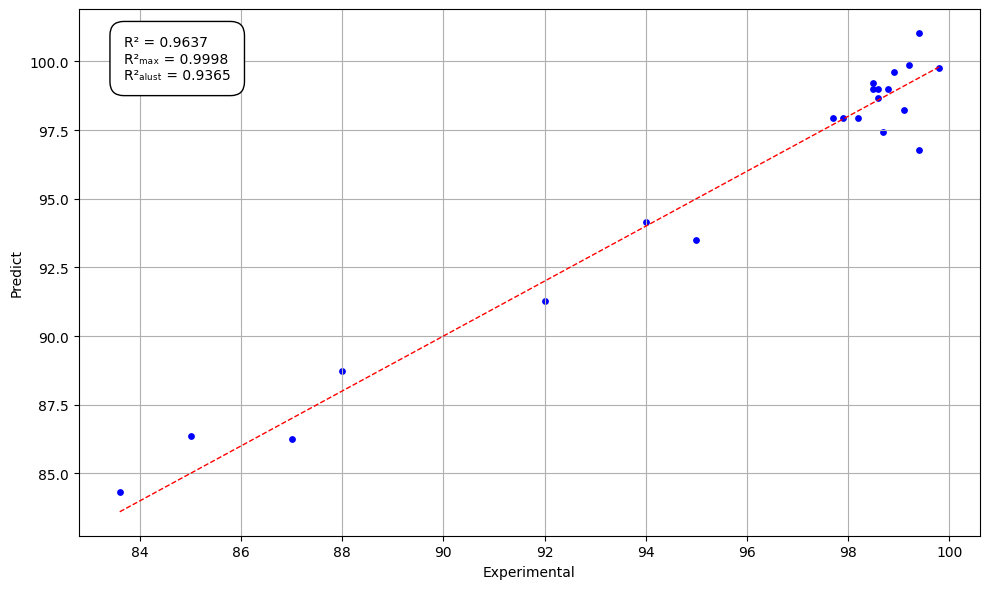

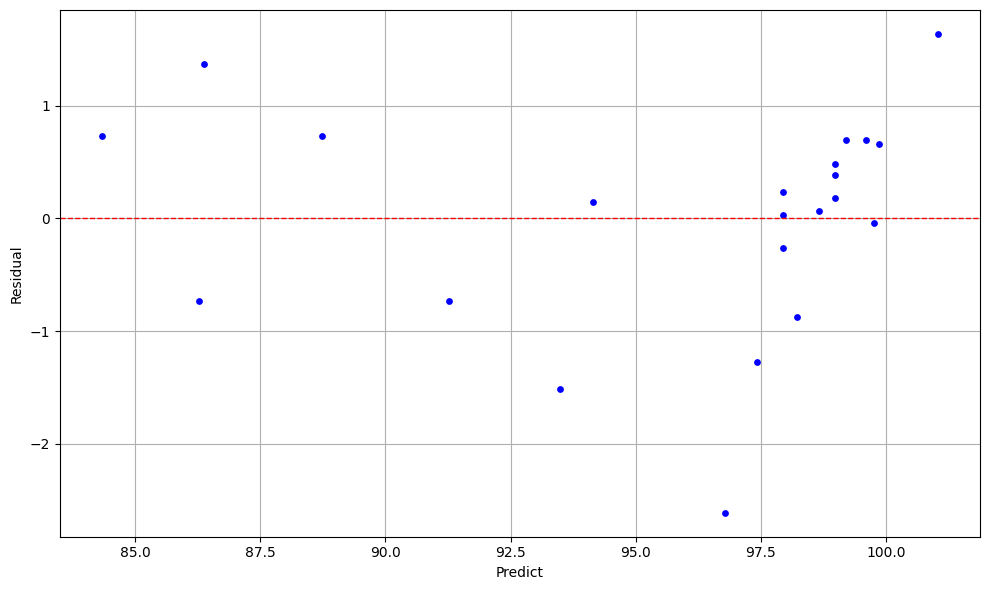

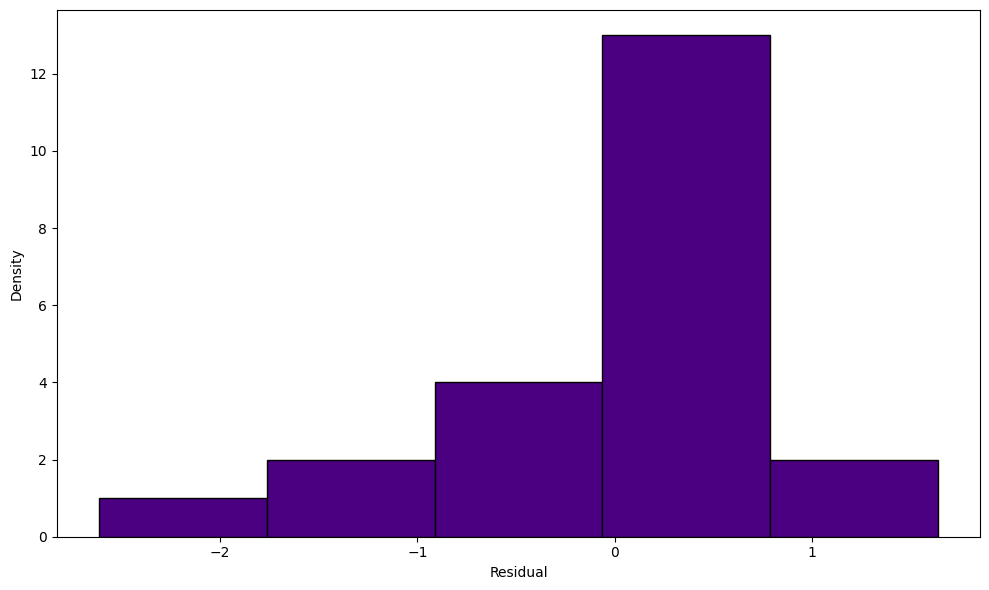

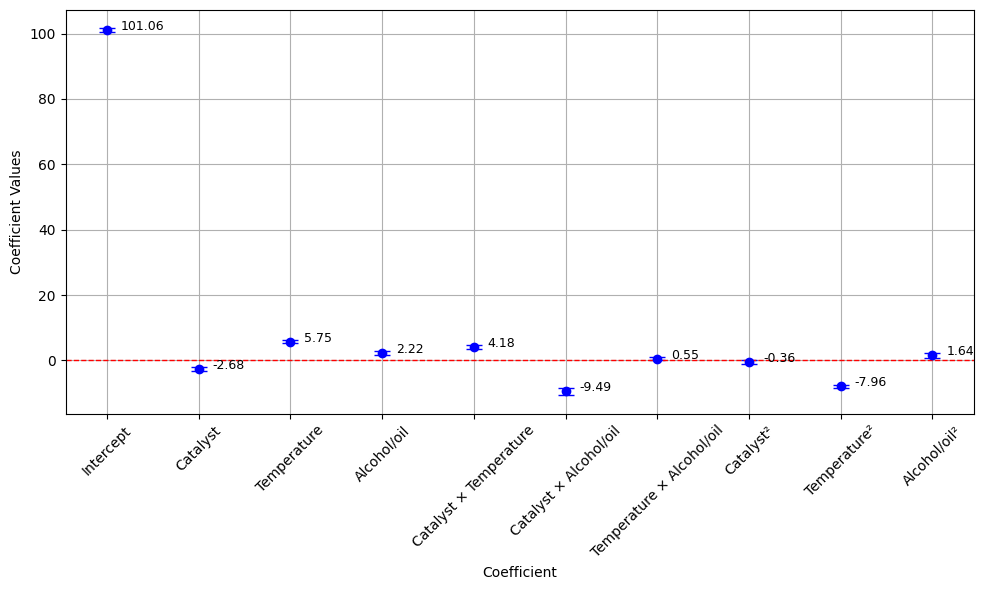

In [22]:
doe.Regression(X8,y8e,yc8e, type_matrix='interaction', order=2, effect_error='cp').analysis

In [23]:
doe.Regression(X8,y8e,yc8e, type_matrix='interaction', order=2, effect_error='cp').coefficient

,Term,Coefficient,Error,Significant
0,Intercept,101.0580,±0.5527,True
1,Catalyst,-2.6835,±0.6176,True
2,Temperature,5.7459,±0.5057,True
3,Alcohol/oil,2.2212,±0.5429,True
4,Catalyst × Temperature,4.1756,±0.6036,True
5,Catalyst × Alcohol/oil,-9.4874,±1.1596,True
6,Temperature × Alcohol/oil,0.5520,±0.5285,True
7,Catalyst²,-0.3573,±0.6224,False
8,Temperature²,-7.9630,±0.4313,True
9,Alcohol/oil²,1.6381,±0.7798,True


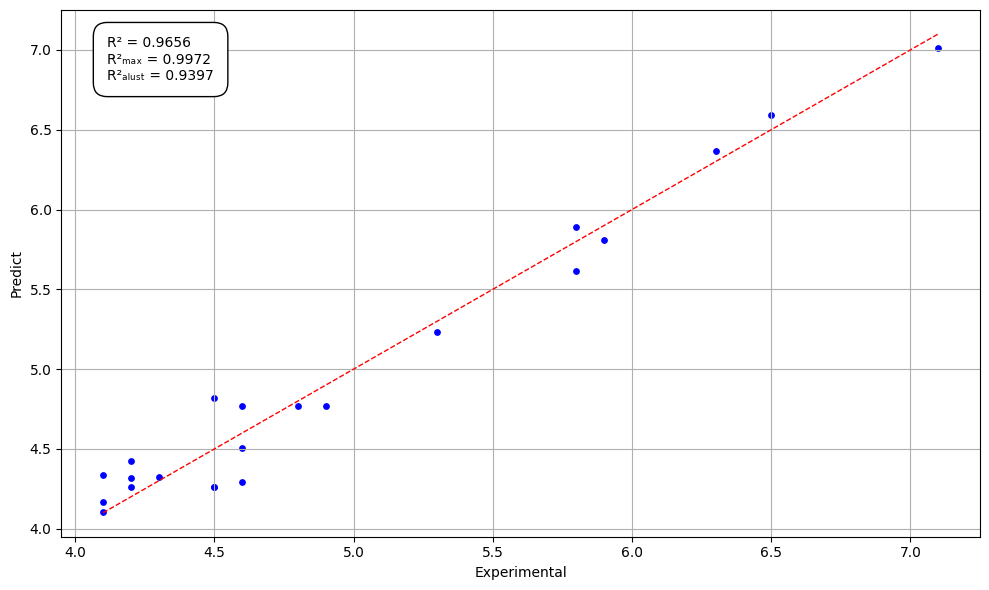

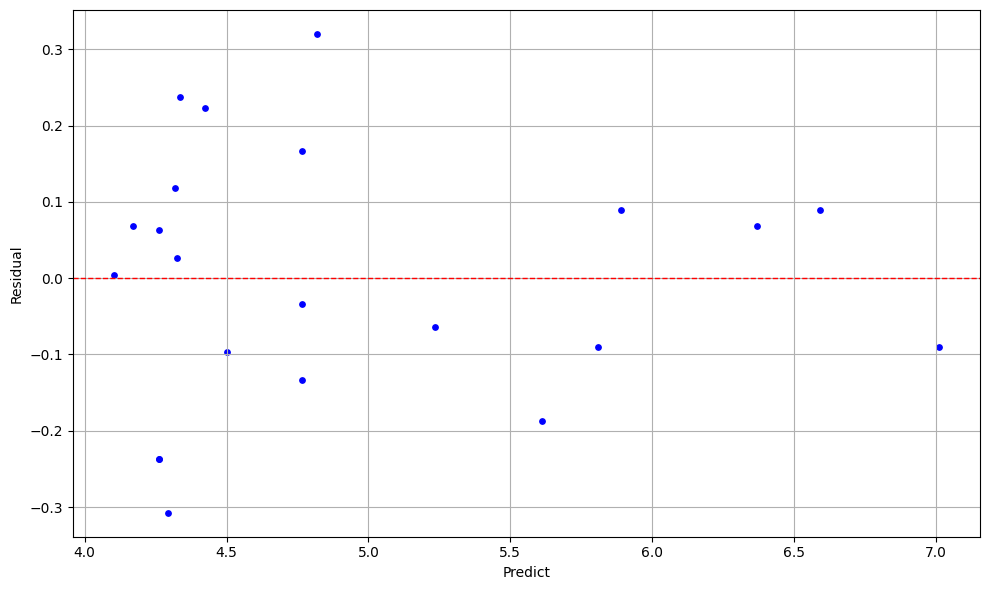

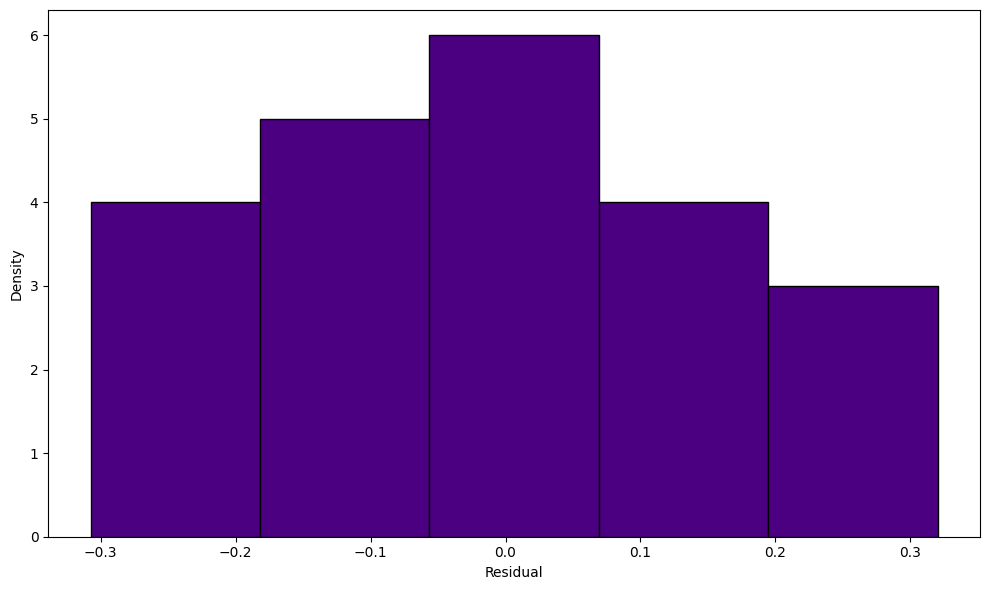

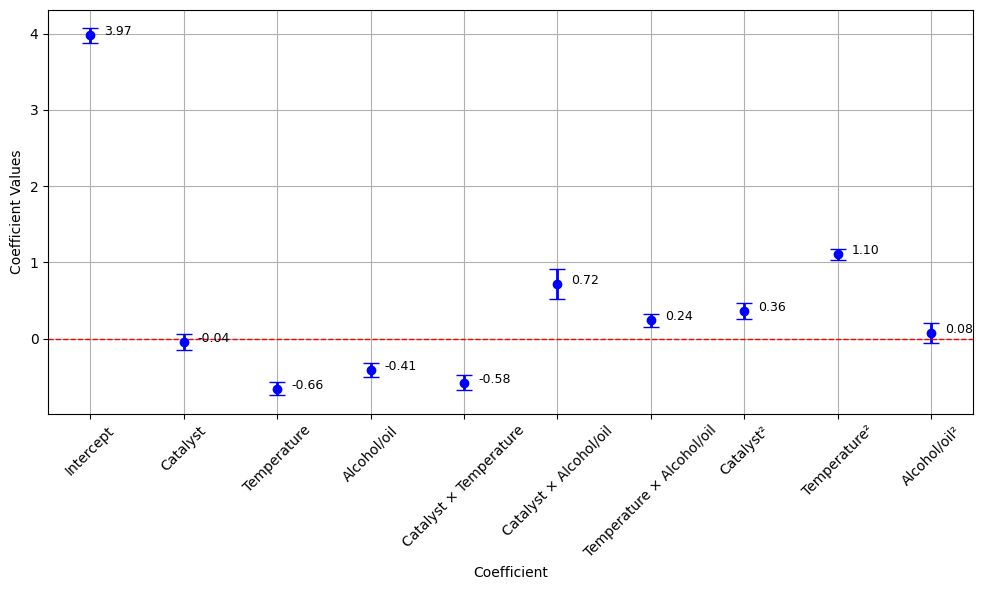

In [24]:
doe.Regression(X8,y8v,yc8v, type_matrix='interaction', order=2, effect_error='cp').analysis

In [25]:
doe.Regression(X8,y8v,yc8v, type_matrix='interaction', order=2, effect_error='cp').coefficient

,Term,Coefficient,Error,Significant
0,Intercept,3.9747,±0.0929,True
1,Catalyst,-0.0385,±0.1038,False
2,Temperature,-0.6559,±0.0850,True
3,Alcohol/oil,-0.4129,±0.0913,True
4,Catalyst × Temperature,-0.5752,±0.1014,True
5,Catalyst × Alcohol/oil,0.7214,±0.1949,True
6,Temperature × Alcohol/oil,0.2400,±0.0888,True
7,Catalyst²,0.3570,±0.1046,True
8,Temperature²,1.1047,±0.0725,True
9,Alcohol/oil²,0.0802,±0.1311,False


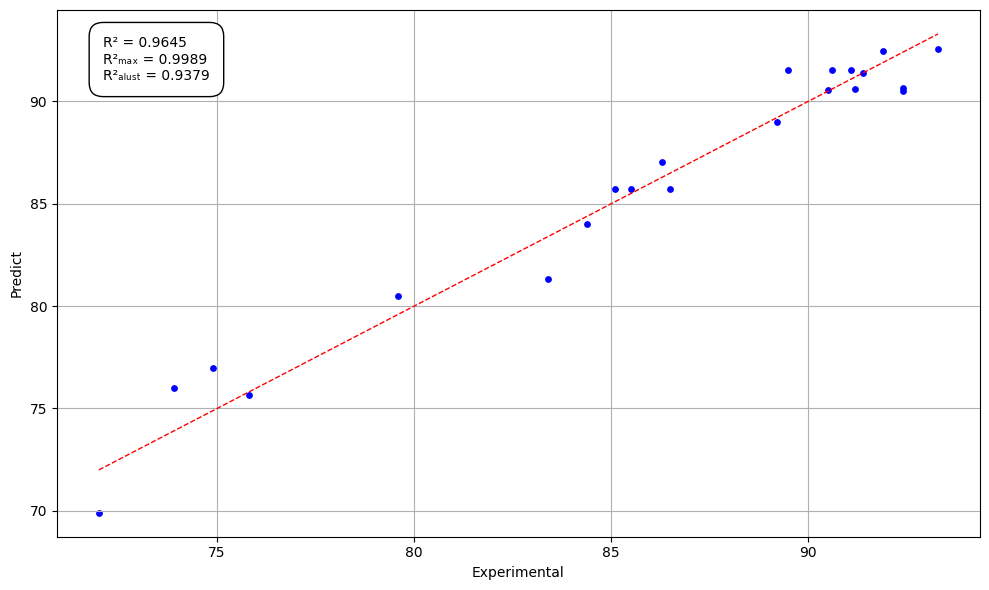

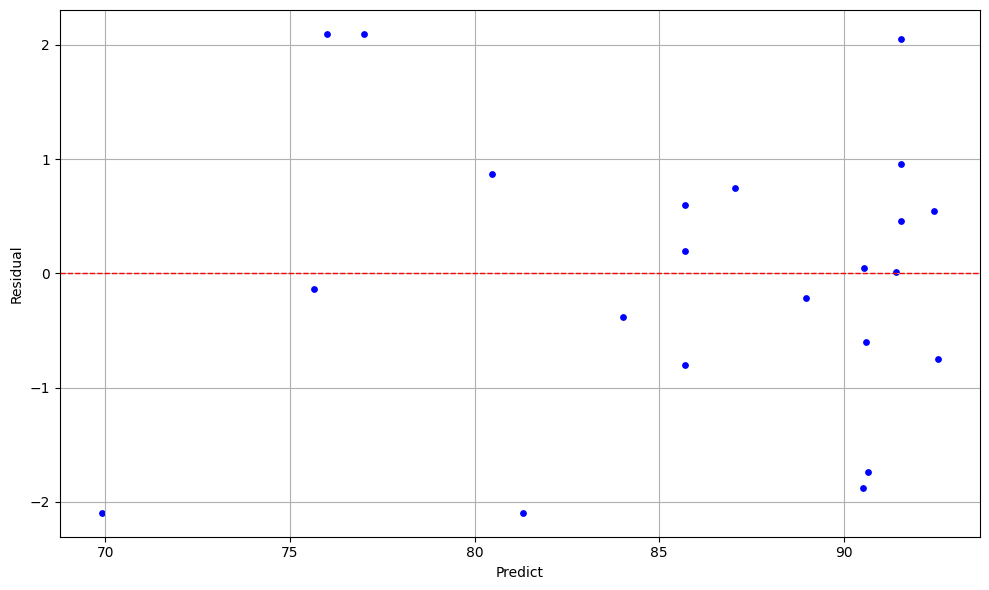

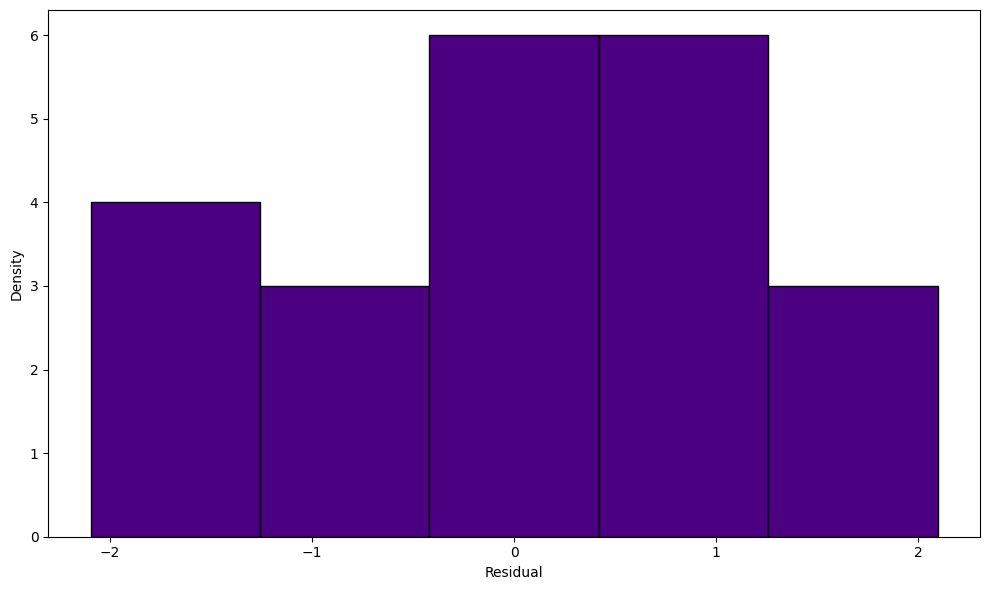

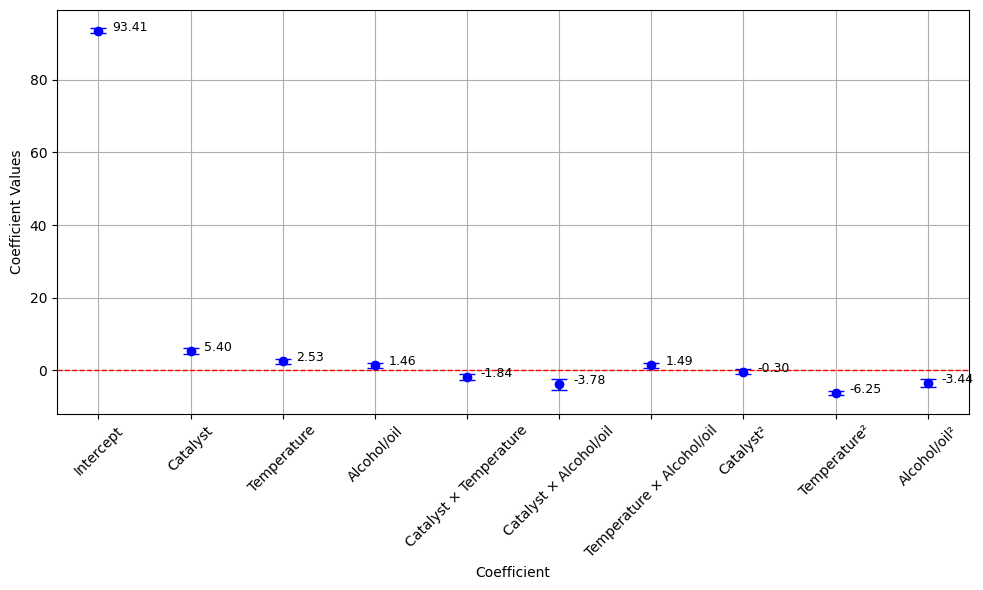

In [26]:
doe.Regression(X8,y8y,yc8y, type_matrix='interaction', order=2, effect_error='cp').analysis

In [27]:
doe.Regression(X8,y8y,yc8y, type_matrix='interaction', order=2, effect_error='cp').coefficient

,Term,Coefficient,Error,Significant
0,Intercept,93.4133,±0.7087,True
1,Catalyst,5.4002,±0.7918,True
2,Temperature,2.5282,±0.6483,True
3,Alcohol/oil,1.4609,±0.6961,True
4,Catalyst × Temperature,-1.8416,±0.7738,True
5,Catalyst × Alcohol/oil,-3.7836,±1.4868,True
6,Temperature × Alcohol/oil,1.4890,±0.6776,True
7,Catalyst²,-0.2988,±0.7979,False
8,Temperature²,-6.2496,±0.5530,True
9,Alcohol/oil²,-3.4351,±0.9997,True


#### Ishrat el al. (2019) *Optimizing the Expanded Polystyrene using Taguchi method*

In [28]:
df9 =  pd.read_excel("test.xlsx", sheet_name = "Ishrat1")
X9 = df9.iloc[:,:3]
y9 = df9.iloc[:,3:6]


,Factor/Interactions,Weight (Kg),Duration (s),Temperature (◦F)
0,Level 1,-212.012430,-214.222267,-219.047861
1,Level 2,-213.031911,-216.792431,-215.099943
2,Level 3,-220.410459,-214.440102,-211.306996


,Factor/Interactions,Weight (Kg),Duration (s),Temperature (◦F)
0,Level 1,-23.556937,-23.802474,-24.338651
1,Level 2,-23.670212,-24.088048,-23.899994
2,Level 3,-24.490051,-23.826678,-23.478555
3,Difference,0.933114,0.285574,0.860096
4,Order,1.000000,3.000000,2.000000


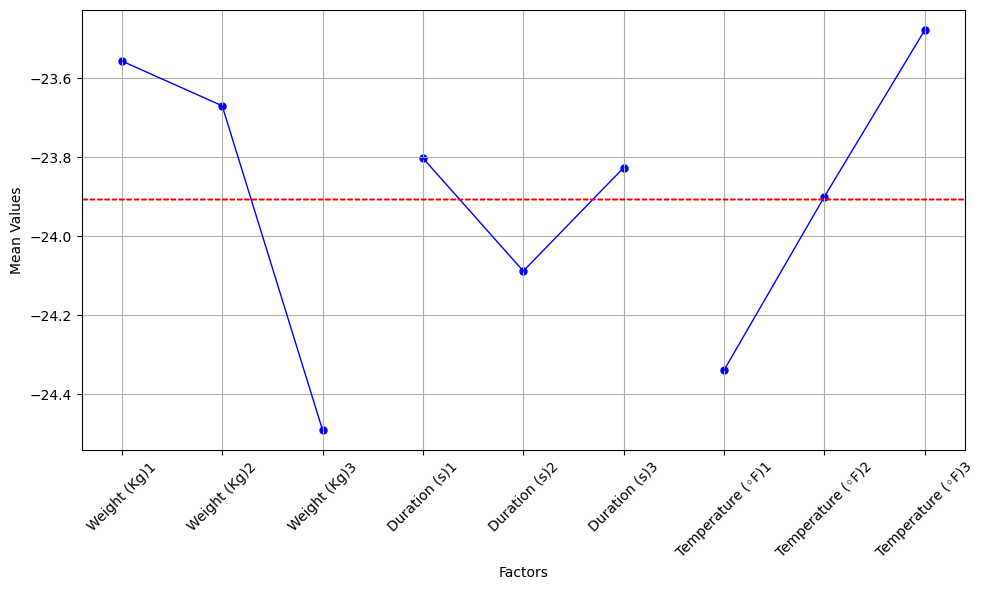

In [29]:
doe.Taguchi(X9,y9,sn = 'min').effect_analysis

Combination,Mean
Weight (Kg)1Duration (s)1,-23.451510
Weight (Kg)1Duration (s)2,-23.748532
Weight (Kg)1Duration (s)3,-23.470768
Weight (Kg)2Duration (s)1,-23.501714
Weight (Kg)2Duration (s)2,-23.879771
Weight (Kg)2Duration (s)3,-23.629151
Weight (Kg)3Duration (s)1,-24.454198
Weight (Kg)3Duration (s)2,-24.635841
Weight (Kg)3Duration (s)3,-24.380115


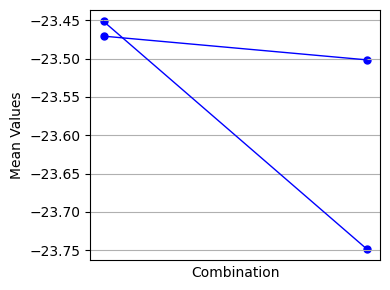

Combination,Mean
Weight (Kg)1Temperature (◦F)1,-23.742742
Weight (Kg)1Temperature (◦F)2,-23.722232
Weight (Kg)1Temperature (◦F)3,-23.205836
Weight (Kg)2Temperature (◦F)1,-24.205994
Weight (Kg)2Temperature (◦F)2,-23.578085
Weight (Kg)2Temperature (◦F)3,-23.226558
Weight (Kg)3Temperature (◦F)1,-25.067217
Weight (Kg)3Temperature (◦F)2,-24.399664
Weight (Kg)3Temperature (◦F)3,-24.003272


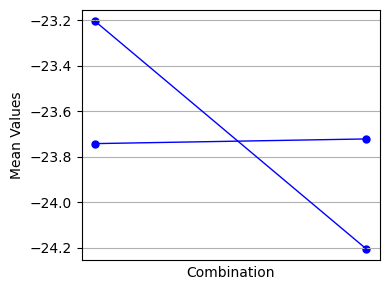

Combination,Mean
Duration (s)1Temperature (◦F)1,-24.487212
Duration (s)1Temperature (◦F)2,-23.497174
Duration (s)1Temperature (◦F)3,-23.423036
Duration (s)2Temperature (◦F)1,-24.439645
Duration (s)2Temperature (◦F)2,-24.386680
Duration (s)2Temperature (◦F)3,-23.437818
Duration (s)3Temperature (◦F)1,-24.089096
Duration (s)3Temperature (◦F)2,-23.816126
Duration (s)3Temperature (◦F)3,-23.574811


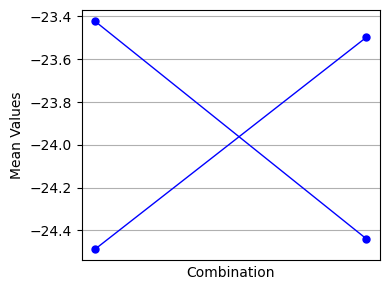

In [30]:
doe.Taguchi(X9,y9,sn = 'min').check_interaction(factors='Weight (Kg),Duration (s)')
doe.Taguchi(X9,y9,sn = 'min').check_interaction(factors='Weight (Kg),Temperature (◦F)')
doe.Taguchi(X9,y9,sn = 'min').check_interaction(factors='Duration (s),Temperature (◦F)')

In [31]:
doe.Taguchi(X9,y9,sn='min').anova(method='Replica')

,Variables,Sum of Squares,Df,Mean of Squares,F-test,C(%),Order
0,Weight (Kg),4.667008,2,2.333504,39.153758,40.004966,1
1,Duration (s),0.451357,2,0.225679,3.786651,3.868973,3
2,Temperature (◦F),3.329389,2,1.664695,27.931837,28.539078,2
3,Residual,3.218317,54,0.059598,,27.586983,
4,Total,11.666071,60,,F(0.05;1;54) = 3.17,100.000000,


In [32]:
doe.Taguchi(X9,y9,sn='min').anova(method='Replica', column_error=['Duration (s)'])

,Variables,Sum of Squares,Df,Mean of Squares,F-test,C(%),Order
0,Weight (Kg),4.667008,2,2.333504,35.60976,40.004966,1
1,Temperature (◦F),3.329389,2,1.664695,25.403589,28.539078,2
2,Residual,3.669674,56,0.06553,,31.455956,
3,Total,11.666071,60,,F(0.05;1;56) = 3.16,100.000000,


In [33]:
doe.Taguchi(X9,y9,sn='min').pred(factors='Weight (Kg)-1,Duration (s)-1,Temperature (◦F)-3')

In [34]:
doe.Taguchi(X9,y9,sn='min').ri(sn0=-23.20,sn1=-23.03)

In [35]:
df9 =  pd.read_excel("test.xlsx", sheet_name = "Ishrat2")
X9 = df9.iloc[:,:13]
y9 = df9.iloc[:,13:]

In [36]:
doe.Taguchi(X9,y9,sn='min').anova(method='Replica', column_error=['e','e.1','e.2','e.3','e.4','e.5','e.6'])

,Variables,Sum of Squares,Df,Mean of Squares,F-test,C(%),Order
0,A,1.016974,2,0.508487,8.326014,8.717368,2
1,B,4.667008,2,2.333504,38.208999,40.004966,1
2,C,0.753346,2,0.376673,6.167675,6.457579,3
3,AB,0.451357,2,0.225679,3.695281,3.868973,5
4,AC,0.110321,2,0.055161,0.903205,0.945659,8
5,BC,0.514162,2,0.257081,4.209467,4.407328,4
6,Residual,4.152903,68,0.061072,,35.598128,
7,Total,11.666071,80,,F(0.05;1;68) = 3.13,100.000000,
